In [ ]:
#Low resolution test code

import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy import integrate


Nx, Ny, Nz = 128, 128, 128
a = 1.0
N_points = Nx * Ny * Nz
# Number of realizations
n_realizations = 1 
base_seed = 42      
all_binned_ratios = [] # Store ratio = (8.0 * np.pi**2 * E_M_vals / k_vals**4) for each realization

for realization in range(n_realizations):
    print(f"Running realization {realization+1}/{n_realizations}")
    np.random.seed(base_seed + realization)  # Different seed for each realization
    
    # Randomized Hopf parameters for each realization
    u = np.random.uniform(-1/2, 1/2, N_points)
    beta = np.random.uniform(0, 2*np.pi, N_points)
    gamma = np.random.uniform(0, 2*np.pi, N_points)

    # Hopf parametrization of the Higgs
    higgs_field = np.column_stack((
        np.sqrt(u + 0.5) * np.exp(1j * beta),
        np.sqrt(0.5 - u) * np.exp(1j * gamma)
    ))

    # reshape to (Nx,Ny,Nz,2)
    phi = higgs_field.reshape(Nx, Ny, Nz, 2)

    # overlap helper
    def overlap(phi1, phi2):
        return np.sum(np.conj(phi1) * phi2, axis=-1)

    # shift helpers with periodic BCs
    def shift(arr, axis, n=1):
        return np.roll(arr, -n, axis=axis)

    # compute Bx from yz-plaquette
    phi0_x = phi                       # (i,j,k)
    phi1_x = shift(phi, 1, 1)          # (i,j+1,k)
    phi2_x = shift(phi1_x, 1, 1)       # (i,j+2,k)
    phi3_x = shift(phi2_x, 2, 1)       # (i,j+2,k+1)
    phi4_x = shift(phi3_x, 2, 1)       # (i,j+2,k+2)
    phi5_x = shift(phi4_x, 1, -1)      # (i,j+1,k+2)
    phi6_x = shift(phi5_x, 1, -1)      # (i,j,k+2)
    phi7_x = shift(phi6_x, 2, -1)      # (i,j,k+1)

    sum_gauge_x = (
        overlap(phi0_x, phi1_x) +
        overlap(phi1_x, phi2_x) +
        overlap(phi2_x, phi3_x) +
        overlap(phi3_x, phi4_x) +
        overlap(phi4_x, phi5_x) +
        overlap(phi5_x, phi6_x) +
        overlap(phi6_x, phi7_x) +
        overlap(phi7_x, phi0_x)
    )
    Bx = np.imag(sum_gauge_x) / (4*a*a)

    # compute By from xz-plaquette
    phi0_y = phi                       # (i,  j, k)
    phi1_y = shift(phi, 2, 1)          # (i,  j, k+1)
    phi2_y = shift(phi1_y, 2, 1)       # (i,  j, k+2)
    phi3_y = shift(phi2_y, 0, 1)       # (i+1,j, k+2)
    phi4_y = shift(phi3_y, 0, 1)       # (i+2,j, k+2)
    phi5_y = shift(phi4_y, 2, -1)      # (i+2,j, k+1)
    phi6_y = shift(phi5_y, 2, -1)      # (i+2,j, k)
    phi7_y = shift(phi6_y, 0, -1)      # (i+1,j, k)

    sum_gauge_y = (
        overlap(phi0_y, phi1_y) +
        overlap(phi1_y, phi2_y) +
        overlap(phi2_y, phi3_y) +
        overlap(phi3_y, phi4_y) +
        overlap(phi4_y, phi5_y) +
        overlap(phi5_y, phi6_y) +
        overlap(phi6_y, phi7_y) +
        overlap(phi7_y, phi0_y)
    )

    By = np.imag(sum_gauge_y) / (4*a*a)

    # compute Bz from xy-plaquette
    phi0_z = phi                       # (i,j,k)
    phi1_z = shift(phi, 0, 1)          # (i+1,j,k)
    phi2_z = shift(phi1_z, 0, 1)       # (i+2,j,k)
    phi3_z = shift(phi2_z, 1, 1)       # (i+2,j+1,k)
    phi4_z = shift(phi3_z, 1, 1)       # (i+2,j+2,k) 
    phi5_z = shift(phi4_z, 0, -1)      # (i+1,j+2,k)
    phi6_z = shift(phi5_z, 0, -1)      # (i,j+2,k)
    phi7_z = shift(phi6_z, 1, -1)      # (i,j+1,k)

    sum_gauge_z = (
        overlap(phi0_z, phi1_z) +
        overlap(phi1_z, phi2_z) +
        overlap(phi2_z, phi3_z) +
        overlap(phi3_z, phi4_z) +
        overlap(phi4_z, phi5_z) +
        overlap(phi5_z, phi6_z) +
        overlap(phi6_z, phi7_z) +
        overlap(phi7_z, phi0_z) 
    )
    Bz = np.imag(sum_gauge_z) / (4*a*a)
    # move staggered 2x2-plaquette-centered components onto vertices
    Bx_v = np.roll(np.roll(Bx, 1, axis=1), 1, axis=2)  # (j+1,k+1) -> (j,k)
    By_v = np.roll(np.roll(By, 1, axis=0), 1, axis=2)  # (i+1,k+1) -> (i,k)
    Bz_v = np.roll(np.roll(Bz, 1, axis=0), 1, axis=1)  # (i+1,j+1) -> (i,j)

    B = np.stack([Bx_v, By_v, Bz_v], axis=-1)


#######################################################################################################################################    
# Fourier transform to get B-field modes in k-space and group modes by shells of equal radii.


    Ntot = Nx * Ny * Nz
    b_k = np.fft.fftn(B, axes=(0,1,2)) #/ np.sqrt(Ntot)

    # k-vectors (Fourier frequencies)
    kx = 2*np.pi * np.fft.fftfreq(Nx, d=a)
    ky = 2*np.pi * np.fft.fftfreq(Ny, d=a)
    kz = 2*np.pi * np.fft.fftfreq(Nz, d=a)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')

    # FFT mode integer indices
    iX = np.fft.fftfreq(Nx) * Nx
    iY = np.fft.fftfreq(Ny) * Ny
    iZ = np.fft.fftfreq(Nz) * Nz
    IX, IY, IZ = np.meshgrid(iX, iY, iZ, indexing='ij')

    # Compute integer shell index (lattice radius)
    n_sq = (IX**2 + IY**2 + IZ**2).astype(int)
    flat_n = n_sq.ravel()

    # Flatten the squared magnitude of b_k (sum over components)
    flat_bsq = np.sum(np.abs(b_k)**2, axis=3).ravel()

    # Use defaultdict to accumulate modes per shell 
    k_dict = defaultdict(list)
    for n, val in zip(flat_n, flat_bsq):
        k_dict[n].append(val)

    # Convert lists to arrays
    for n in k_dict:
        k_dict[n] = np.array(k_dict[n])

    print("Number of shells:", len(k_dict.keys()))


#######################################################################################################################################

    L = Nx * a
    V = L**3
    k_1 = 2*np.pi / L   

    Pk_times_k2 = {}
    for n2 in sorted(k_dict.keys()):
        if n2 == 0:  # Skip k=0 mode
            continue
        power = np.mean(k_dict[n2])
        k_phys = np.sqrt(n2) * k_1
        Pk_times_k2[k_phys] = power * k_phys**2

    # Calculate E_M(k)
    E_M = {k: val / (4 * np.pi**2 * V) for k, val in Pk_times_k2.items()}

    # Prepare arrays for integration
    k_vals = np.array(sorted(E_M.keys()))
    E_M_vals = np.array([E_M[k] for k in k_vals])


    #den = integrate.simpson(y = E_M_vals / k_vals**5,x = k_vals)

    #ratio = (E_M_vals / k_vals**4) / den
    ratio = (8.0 * np.pi**2 * E_M_vals / k_vals**4)# / den


    # Convert to dimensionless k units
    k_ratio = k_vals / k_1

    # Bin by integer n values
    n_max = int(np.max(k_ratio))
    bin_centers = np.arange(1, n_max+1)

    binned_k = []
    binned_ratio = []

    for n in bin_centers:
        # Define range [n-0.5, n+0.5)
        mask = (k_ratio >= (n-0.5)) & (k_ratio < (n+0.5))
        if np.any(mask):
            avg_val = np.mean(ratio[mask])
            binned_k.append(n)
            binned_ratio.append(avg_val)

    binned_k = np.array(binned_k)
    binned_ratio = np.array(binned_ratio)
    
    # Store the binned ratio for this realization
    all_binned_ratios.append(binned_ratio)

all_binned_ratios = np.array(all_binned_ratios)
avg_binned_ratio = np.mean(all_binned_ratios, axis=0)

#######################################################################################################################################
#Plotting

k_nyq = np.pi / a     # Nyquist in 1D
k_nyq_ratio = k_nyq / k_1   # in units of k1

# define continuous physical k-grid only up to Nyquist
k_phys_min = np.min(k_vals[k_vals > 0])
k_phys_max = k_nyq
k_phys_cont = np.linspace(k_phys_min, k_phys_max, 500)
sinc_ka = np.where(k_phys_cont * a == 0.0, 1.0, np.sin(k_phys_cont * a) / (k_phys_cont * a))
sinc_2ka = np.where(k_phys_cont * a == 0.0, 1.0, np.sin(2* k_phys_cont * a) / (2 * k_phys_cont * a))
sinc_sqrt5ka = np.where(k_phys_cont * a == 0.0, 1.0, np.sin(np.sqrt(5) * k_phys_cont * a) / (np.sqrt(5) * k_phys_cont * a))

# analytic E_M/k^4 from relation
analytic_E_over_k4 = (3.0 / (4.0 * k_phys_cont**2 * a)) * (1.0 + sinc_ka- sinc_2ka - sinc_sqrt5ka)
k_cont = k_phys_cont / k_1

plt.figure(figsize=(8, 6))
# mask bins beyond Nyquist
k_nyq_ratio = (np.pi / a) / k_1
mask_nyq = binned_k <= k_nyq_ratio
plt.semilogx(binned_k[mask_nyq], avg_binned_ratio[mask_nyq], '.', 
             label=f'Averaged Spectrum ({n_realizations} realizations)')
plt.title('Magnetic Energy Spectrum (4PA for $N = 128^3$)')
plt.grid(True, which="both", ls="-")
plt.tight_layout()
#plot analytic spectrum
plt.semilogx(k_cont, analytic_E_over_k4, 'r-',
             label=r'Analytic limit $8\pi²E_{M,4PA}(k)/k^4 = \frac{3}{4k²a}[1 + j_{0}(ka) - j_{0}(2ka) - j_{0}(\sqrt{5}ka)]$')
plt.axvline(k_nyq_ratio, color='k', linestyle=':', label=r'$|k_{\rm Nyq}|/k_{1}$')
plt.xlabel(r"$|k|/k_1$")
plt.ylabel(r"$8\pi²E_M(k)/k^4$[in units of 1/k₁]")
plt.legend(loc='lower left')
plt.show()


# Vector potential in Fourier space: a_k = - i (k x b_k) / k^2
k2 = KX**2 + KY**2 + KZ**2
a_k = np.zeros_like(b_k, dtype=np.complex128)

mask_k = k2 > 0
a_k[mask_k] = -1j * np.cross(
    np.stack((KX[mask_k], KY[mask_k], KZ[mask_k]), axis=-1),
    b_k[mask_k]
) / k2[mask_k, None]


flat_ab = np.real(np.sum(a_k * np.conj(b_k), axis=3)).ravel()


h_dict = defaultdict(list)
for n, val in zip(flat_n, flat_ab):
    h_dict[n].append(val)

for n in h_dict:
    h_dict[n] = np.array(h_dict[n])

# Helicity spectrum H_M(k)
H_M = {}
for n2 in sorted(h_dict.keys()):
    if n2 == 0:
        continue
    hel = np.mean(h_dict[n2])
    k_phys = np.sqrt(n2) * k_1
    H_M[k_phys] = hel * k_phys**2 / (4 * np.pi**2 * V)

H_M_vals = np.array([H_M[k] for k in k_vals])
ratio_H = (8.0 * np.pi**2 * H_M_vals / k_vals**4)

plt.figure(figsize=(8, 6))
plt.semilogx(k_vals / k_1, ratio_H, ':')
plt.axhline(0.0, color='k', linestyle=':')
plt.title('Magnetic Helicity Spectrum 4PA')
plt.xlabel(r"$|k|/k_1$")
plt.ylabel(r"$8\pi^{2}H_M(k)/k^{4}$")
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()


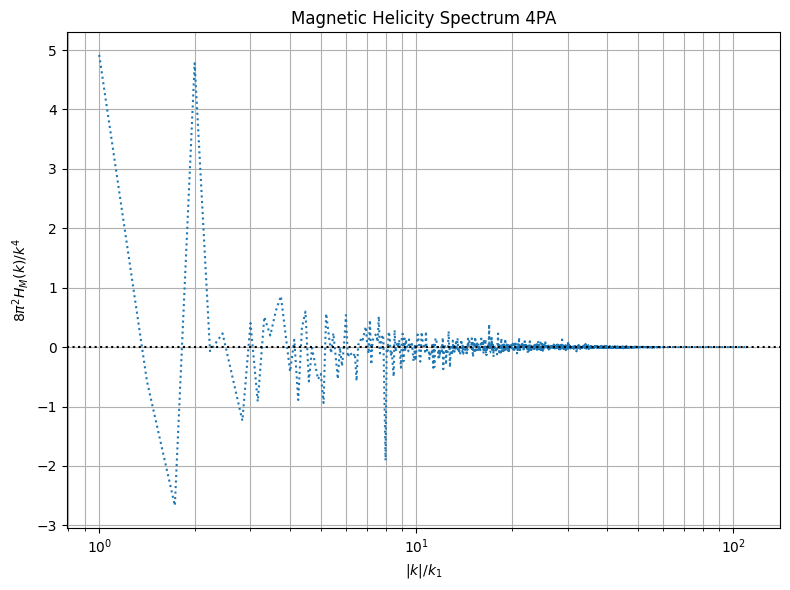